# Lista 9

## NLTK, HuggingFace, PytorchGeometric

(6pkt + 3pkt)

Na liście znajdują się 3 zadania. Po rozwiązaniu zadań, pokaż kod prowadzącemu i odpowiedz na **pytanie kontrolne** — tylko wtedy przyznajemy punkty. Dodatkowo prześlij zadanie na platformie skos.

**Uwaga**

Jeśli nie jesteś obecny/obecna na ćwiczeniach, odpowiedz na wszystkie pytania pisemnie. Na kolejnych ćwiczeniach możesz być poproszony/poproszona o wytłumaczenie fragmentu kodu w celu sprawdzenia, czy zadanie wykonałeś/wykonałaś samodzielnie. Jeśli zostanie wykryte, że nie rozumiesz swojego rozwiązania - punkty zostaną skreślone. (Nie musisz rozumieć bardzo szczegółowo jak działa konkretna funkcja, ale wymagane jest rozumienie sensu, np. na pytanie co to jest `GNN` (grafowa sieć neuronowa) bardzo dobrą odpowiedzią jest "GNN to grafowa sieć neuronowa, czyli sieć neuronowa, która przetwarza grafy. Grafy to obiekty złożone z wierzchołków i krawędzi, które mówią o relacjach między wiierzchołkami." Nie zostaniesz zapytany o to co robi konkretna warstwa w tej sieci.)

**Zadania bonusowe**
Dodatkowe zadania na wyższą ocenę oznaczone są ⭐️. Zadanie z HuggingFace warte jest 1pkt, a z PytorchGeometric 2pkt.

## NLP z użyciem NLTK i WordCloud (2.5pkt)

1. Pobierz **dowolny tekst z Internetu** (np. artykuł, esej, fragment książki, piosenkę).
2. Zapisz tekst w pliku `tekst.txt`.
3. Wczytaj plik w Pythonie.
4. Zastosuj **co najmniej 3 techniki preprocessingu tekstu** poznane na wykładzie.
5. Na podstawie przetworzonego tekstu wygeneruj **wykres WordCloud**.

Pytania kontrolne:

1. Krótko (2–3 zdania) opisz, jakie techniki preprocessingu zastosowałeś/aś i dlaczego.
2. Co mozesz odczytać z wykresu?

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


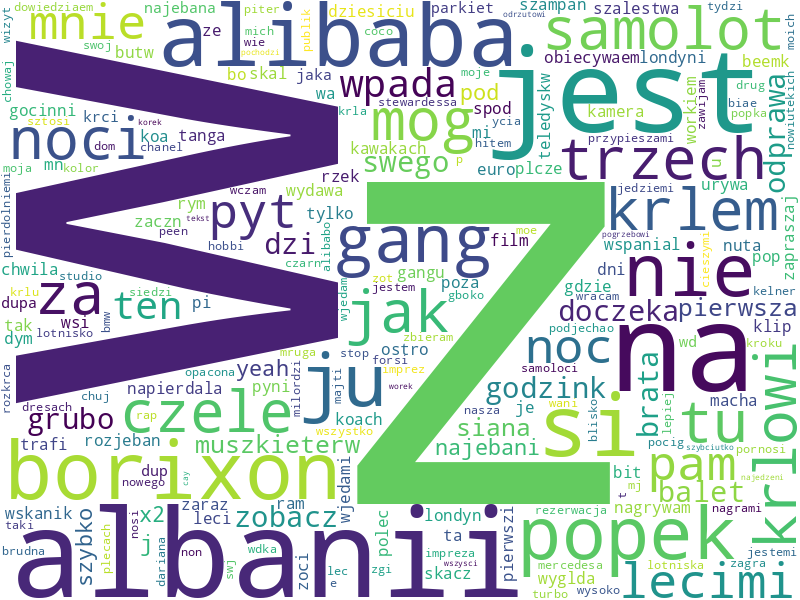

In [ ]:
import re
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt_tab')

# Wczytanie pliku
with open("tekst.txt", "r", encoding="utf-8") as f:
    text = f.read()

clean_text = text.lower()
clean_text = re.sub(r"[^a-z0-9\s]", "", clean_text) # usuwamy wszystkie znaki poza literami i cyframi
clean_text = re.sub(r"\s+", " ", clean_text).strip() # usuwamy \n

clean_text = word_tokenize(clean_text)

stemmer = PorterStemmer()
clean_text = [stemmer.stem(word) for word in clean_text]

clean_text_str = " ".join(clean_text)
wordcloud = WordCloud(
    background_color="white",
    max_words=1000,
    width=800,
    height=600
)

wordcloud.generate(clean_text_str)
wordcloud.to_image()

In [ ]:
len(clean_text)

380

## Klasyfikacja tematyczna tekstu (1.5pkt)

### Opis problemu

Masz krótkie artykuły prasowe.
Zadaniem modelu jest automatycznie odpowiedzieć na pytanie:

**Do jakiej kategorii tematycznej należy dany tekst?**

Użyj datasetu **AG News**, który zawiera: krótkie artykuły prasowe z 4 klas tematycznych.

Klasy:

```
0 – World
1 – Sports
2 – Business
3 – Sci/Tech
```

### Treść zadania

1. Załaduj dataset **AG News** z biblioteki `datasets` (`load_dataset("ag_news", split="test[:5]")`).
2. Załaduj gotowy model Transformer do **klasyfikacji tekstu** (`"text-classification"`, `model="textattack/bert-base-uncased-ag-news"`).
3. Uruchom model na wybranych przykładach z datasetu.
4. Wyświetl:

   * oryginalny tekst,
   * przewidzianą klasę,
   * prawdopodobną etykietę (np. *Sports*).

Pytania kontrolne:
1. Co się stanie jeśli usuniesz argument `model` z pipeline? Jaki model zwróci pipeline?
2. Czy mozesz uzyć tego konkretnego modelu bez pipeline? Jeśli tak, to w jaki sposób?

In [ ]:
from datasets import load_dataset
from transformers import pipeline

# Dataset
dataset = load_dataset("ag_news", split="test[:5]")

# Mapowanie etykiet AG News
label_map = {
    "LABEL_0": "World",
    "LABEL_1": "Sports",
    "LABEL_2": "Business",
    "LABEL_3": "Sci/Tech"
}

# Dedykowany Transformer
classifier = pipeline("text-classification", model="textattack/bert-base-uncased-ag-news")


# Predykcja
for example in dataset:
    text = example["text"]
    true_label = label_map[f"LABEL_{example['label']}"]

    prediction = classifier(text)[0]
    predicted_label = label_map[prediction['label']]

    print("TEKST:")
    print(text[:300], "...\n")
    print(f"Prawdziwa klasa: {true_label}")
    print(f"Predykcja modelu: {predicted_label} (score={prediction['score']:.2f})")
    print("-" * 60)


Device set to use cpu


TEKST:
Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul. ...

Prawdziwa klasa: Business
Predykcja modelu: Business (score=1.00)
------------------------------------------------------------
TEKST:
The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest for\privately funded suborbital space flight, has officially announced the first\launch date f ...

Prawdziwa klasa: Sci/Tech
Predykcja modelu: Sci/Tech (score=1.00)
------------------------------------------------------------
TEKST:
Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building blocks of p

## Hugging Face Spaces (1pkt)

### Treść zadania

1. Wejdź na platformę **Hugging Face Spaces**.
2. Wybierz **jedną istniejącą aplikację**.
3. Uruchom aplikację i przetestuj ją na własnym przykładzie.

Pytania kontrolne:
Brak - zademonstruj wyniki podczas ćwiczeń.

## ⭐️ Question Answering

### Opis zadania

Zadaniem modelu jest automatyczne odpowiadanie na różne pytania na podstawie fragmentów tekstu.

### Treść zadania

1. Załaduj dataset **SQuAD** (``squad``).
2. Wybierz kilka przykładów (np. 5: ``split="validation[:5]"``) i wypisz je, żeby zobaczyć z jakimi danymi i etykietami będziesz pracować.
3. Załaduj model Transformer do **Question Answering**. Użyj `pipeline` (zadanie: ``question-answering``, model: ``distilbert-base-uncased-distilled-squad``).
4. Uruchom model w pętli dla tych kilku przykładów. Porównaj odpowiedzi modelu z poprawnymi odpowiedziami z datasetu.
5. Krótko opisz wnioski.

Device set to use mps:0


PRZYKŁAD 1
PYTANIE:
Which NFL team represented the AFC at Super Bowl 50?

ODPOWIEDŹ MODELU:
Denver Broncos
(score=0.99)

POPRAWNA ODPOWIEDŹ:
Denver Broncos
PRZYKŁAD 2
PYTANIE:
Which NFL team represented the NFC at Super Bowl 50?

ODPOWIEDŹ MODELU:
Carolina Panthers
(score=1.00)

POPRAWNA ODPOWIEDŹ:
Carolina Panthers
PRZYKŁAD 3
PYTANIE:
Where did Super Bowl 50 take place?

ODPOWIEDŹ MODELU:
Levi's Stadium
(score=0.50)

POPRAWNA ODPOWIEDŹ:
Santa Clara, California
PRZYKŁAD 4
PYTANIE:
Which NFL team won Super Bowl 50?

ODPOWIEDŹ MODELU:
Denver Broncos
(score=0.26)

POPRAWNA ODPOWIEDŹ:
Denver Broncos
PRZYKŁAD 5
PYTANIE:
What color was used to emphasize the 50th anniversary of the Super Bowl?

ODPOWIEDŹ MODELU:
gold
(score=0.98)

POPRAWNA ODPOWIEDŹ:
gold


## ⭐️ Dane grafowe w PyTorch Geometric

### Wczytanie datasetu

1. Wczytaj dataset **ENZYMES** z kolekcji TU Dortmund (``data = TUDataset(root="/tmp/ENZYMES", name="ENZYMES")``).
2. Sprawdź:

   * ile grafów zawiera dataset,
   * ile cech ma każdy wierzchołek (`` dataset.num_classes``),
   * ile jest klas (``dataset.num_node_features``).

---

### Analiza pojedynczego grafu

1. Pobierz **pierwszy graf** z datasetu (``dataset[0]``).
2. Wypisz:

   * liczbę wierzchołków,
   * liczbę krawędzi,
   * rozmiar macierzy cech wierzchołków `x`,
   * etykietę grafu `y`.
3. Sprawdź, czy graf jest skierowany (``.is_undirected()``).

---

### Wizualizacja grafu (Kod jest zaimplementowany - nie musisz nic robić)

1. Narysuj pierwszy graf:

   * wierzchołki jako punkty,
   * krawędzie jako linie.
2. (Opcjonalnie) Pokoloruj wierzchołki według jednej z cech.

---

### DataLoader i batchowanie

1. Utwórz `DataLoader` z:

   * `batch_size = 32`,
   * `shuffle = True`.
2. Pobierz jeden batch i:

   * wypisz go,
   * sprawdź, ile grafów zawiera,
   * wypisz pierwsze kilka wartości wektora `batch`.

Number of graphs in dataset: 600
Number of classes: 6
Number of node features: 3

Single graph:
Data(edge_index=[2, 168], x=[37, 3], y=[1])
Number of nodes: 37
Number of edges: 168
Shape of node features x: torch.Size([37, 3])
Graph label y: 5
Is the graph undirected: True


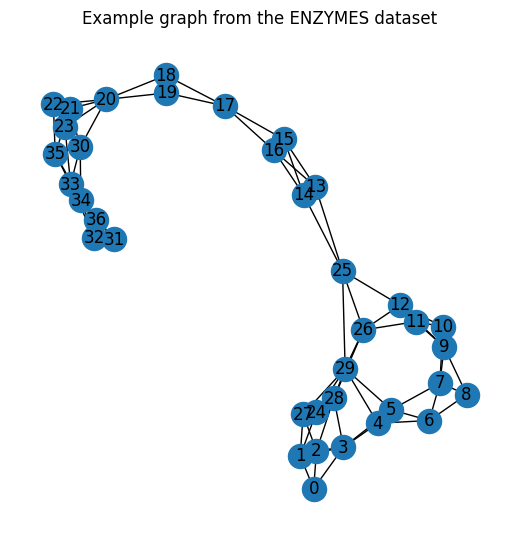


Batch:
DataBatch(edge_index=[2, 3886], x=[1012, 3], y=[32], batch=[1012], ptr=[33])
Number of graphs in batch: 32
Shape of batch vector: torch.Size([1012])
First 10 entries of batch vector: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [ ]:
# ============================================================
# Exploring Graph Data in PyTorch Geometric (ENZYMES dataset)
# ============================================================

# Basic imports
import torch
import matplotlib.pyplot as plt
import networkx as nx

# PyTorch Geometric imports
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx

# ------------------------------------------------------------
# 1. Load the dataset
# ------------------------------------------------------------
# ENZYMES is a graph classification dataset
# Each element in the dataset is a separate graph

dataset = # Uzupełnij

print("Number of graphs in dataset:", # Uzupełnij
print("Number of classes:", # Uzupełnij
print("Number of node features:", # Uzupełnij

# ------------------------------------------------------------
# 2. Inspect a single graph
# ------------------------------------------------------------
# Take the first graph from the dataset

data = dataset[0]

print("\nSingle graph:")
print(# Uzupełnij)

print("Number of nodes:", # Uzupełnij
print("Number of edges:", # Uzupełnij
print("Shape of node features x:", # Uzupełnij
print("Graph label y:", # Uzupełnij
print("Is the graph undirected:", # Uzupełnij

# ------------------------------------------------------------
# 3. Visualize the graph
# ------------------------------------------------------------
# Convert PyG graph to NetworkX for visualization
# This is ONLY for visualization purposes

G = to_networkx(data, to_undirected=True)

plt.figure(figsize=(5, 5))
nx.draw(
    G,
    node_size=300,
    with_labels=True
)
plt.title("Example graph from the ENZYMES dataset")
plt.show()

# ------------------------------------------------------------
# 4. Create a DataLoader and inspect a batch
# ------------------------------------------------------------
# DataLoader merges many graphs into one batch

loader = # Uzupełnij

batch = next(iter(loader))

print("\nBatch:")
print(# Uzupełnij)

print("Number of graphs in batch:", # Uzupełnij
print("Shape of batch vector:", # Uzupełnij

# Show how nodes are assigned to graphs
print("First 10 entries of batch vector:", # Uzupełnij
